In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import LabelEncoder

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("C:/Users/hp/Desktop/4th Sem/jyesta/majo/data/Titanic-Dataset.csv")

# Split into train (80%) and test (20%)
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

# Save as CSV files
train_df.to_csv("../data/train.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (712, 12)
Test shape: (179, 12)


In [14]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(train.head())
print(train.info())

   PassengerId  Survived  Pclass                                Name     Sex  \
0          332         0       1                 Partner, Mr. Austen    male   
1          734         0       2          Berriman, Mr. William John    male   
2          383         0       3                  Tikkanen, Mr. Juho    male   
3          705         0       3             Hansen, Mr. Henrik Juul    male   
4          814         0       3  Andersson, Miss. Ebba Iris Alfrida  female   

    Age  SibSp  Parch             Ticket     Fare Cabin Embarked  
0  45.5      0      0             113043  28.5000  C124        S  
1  23.0      0      0              28425  13.0000   NaN        S  
2  32.0      0      0  STON/O 2. 3101293   7.9250   NaN        S  
3  26.0      1      0             350025   7.8542   NaN        S  
4   6.0      4      2             347082  31.2750   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 12 columns):
 #   Column 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            140
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          553
Embarked         2
dtype: int64


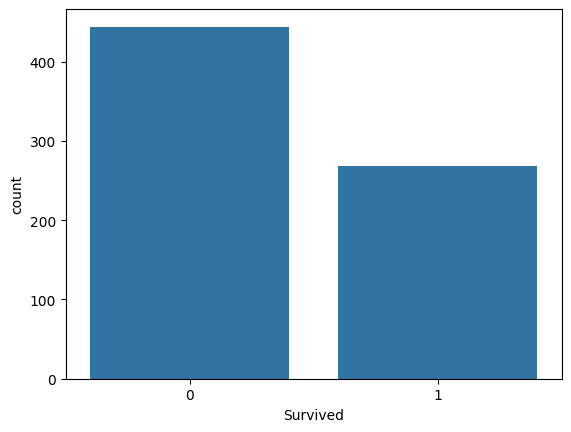

In [ ]:
# data exploration
# missing values :
print(train.isnull().sum())

# Survival Distribution
sns.countplot(x='Survived', data=train)
plt.show()

# Gender vs Survival
sns.barplot(x='Sex', y='Survived', data=train)
plt.show()

# Passenger Class vs Survival
sns.barplot(x='Pclass', y='Survived', data=train)
plt.show()


In [ ]:
# data cleaning
# fill age : 
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

# fill embarked
train['Embarked'].fillna(
    train['Embarked'].mode()[0],
    inplace=True
)

# fill fare
test['Fare'].fillna(
    test['Fare'].median(),
    inplace=True
)

# drop cabin
train.drop('Cabin', axis=1, inplace=True)
test.drop('Cabin', axis=1, inplace=True)



C:\Users\hp\AppData\Local\Temp\ipykernel_2516\2373443786.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_2516\2373443786.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [22]:
# feature engineering

# family size
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

# is alone
train['IsAlone'] = (
    train['FamilySize'] == 1
).astype(int)

test['IsAlone'] = (
    test['FamilySize'] == 1
).astype(int)


In [23]:
# Encode categorical variables
encoder = LabelEncoder()

train['Sex'] = encoder.fit_transform(train['Sex'])
test['Sex'] = encoder.transform(test['Sex'])

train['Embarked'] = encoder.fit_transform(train['Embarked'])
test['Embarked'] = encoder.transform(test['Embarked'])

In [24]:
# selecting the features 
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'FamilySize',
    'IsAlone'
]

X = train[features]
y = train['Survived']

X_test_final = test[features]


In [25]:
# train test split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
# logistic regression 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
# predicting
pred = lr.predict(X_valid)

Accuracy: 0.8041958041958042


classification report : 
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        87
           1       0.75      0.75      0.75        56

    accuracy                           0.80       143
   macro avg       0.79      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143



confusion matrix :


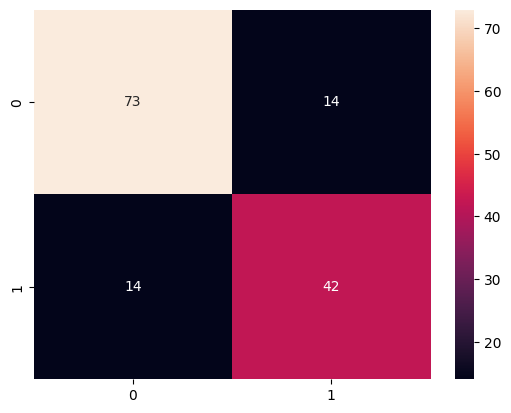

In [33]:
# evaluation : 
# accuracy  :
accuracy = accuracy_score(y_valid, pred)

print("Accuracy:", accuracy)

#  classification report

print("\n\nclassification report : ")
print(
    classification_report(
        y_valid,
        pred
    )
)

# confusion matrix
print("\n\nconfusion matrix :")
cm = confusion_matrix(y_valid, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

In [35]:
#random forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_valid)

print(
    accuracy_score(
        y_valid,
        rf_pred
    )
)

0.7902097902097902


In [37]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [39]:
# final model
best_model = grid.best_estimator_

# saving the model
import joblib

joblib.dump(
    best_model,
    "../models/random_forest.pkl"
)


['../models/random_forest.pkl']

In [40]:
# predicting kaggle test data : 
final_predictions = best_model.predict(
    X_test_final
)

In [45]:
# output submission file
submission = pd.DataFrame({
    "PassengerId":
        test["PassengerId"],
    "Survived":
        final_predictions
})

submission.to_csv(
    "../output/submission.csv",
    index=False
)